# 학습셋 전처리 & 품질 분석

선택한 7개 비행(circle×2, clover×2, figure8×1, oval×2)을 학습용으로 정리한다.

1. **로드/파싱** — 토픽별 CSV (`motor_pwm`/`imu_raw` 의 `values` 는 문자열 배열이라 파싱)
2. **이착륙 제거** — `cmd_full_state` 스트리밍 구간만 남긴다 (이륙·goTo·착륙은 High-Level 이라 cmd 미발행)
3. **타임스탬프 통일** — pose 는 **mocap GT(`/poses`)**, 100 Hz 격자에 보간·병합 → `unified.csv` (드롭 구간은 보간 채움 + `gap` 플래그)
4. **pose(GT) 지연/드롭 점검** — 타임스탬프 간격(dt) 이상 탐지
5. **배터리 vs 출력** — 전압 하강이 모터 출력(PWM)에 미치는 경향


## 0. 설정


In [1]:
import os, csv, re
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

TRAIN = os.path.expanduser('~/Workspace/cf_ws/flight_data/trainset')
RATE  = 100.0      # 통일 격자 [Hz]
GAP_K = 2.5        # nominal dt 의 이 배 넘으면 지연/드롭

SELECTED = [
    'circle_v1.0_5lap_bag_165219',   # 1
    'circle_v2.0_5lap_bag',          # 2  (battery)
    'clover_v1.0_5lap_bag_171804',   # 5  (battery)
    'clover_v2.0_5lap_bag_171633',   # 8  (battery)
    'figure8_v1.0_5lap_bag_165948',  # 9
    'oval_v1.0_5lap_bag',            # 10
    'oval_v2.0_5lap_bag_171439',     # 11 (battery)
]
print(len(SELECTED), '개 데이터셋')

7 개 데이터셋


/home/sungho/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. 로드 & 파싱
`values` 컬럼은 `"array('f', [..])"` 문자열이라 리스트로 파싱한다.


In [2]:
_ARR = re.compile(r'\[([^\]]*)\]')

def _load(path):
    with open(path) as f:
        return list(csv.DictReader(f))

def _t(rows):                       # timestamp_ns -> 초
    return np.array([int(r['timestamp_ns']) for r in rows], float) / 1e9

def _col(rows, key):
    return np.array([float(r[key]) for r in rows])

def _values(rows):                  # "array('f',[a,b,..])" -> (N,k)
    out = []
    for r in rows:
        m = _ARR.search(r['values'])
        out.append([float(v) for v in m.group(1).split(',')] if m else [])
    return np.array(out, float)

def load_dataset(d):
    c = os.path.join(TRAIN, d, 'csv')
    g = lambda n: (_load(os.path.join(c, n)) if os.path.exists(os.path.join(c, n)) else None)
    return dict(gt=g('poses.csv'), est=g('cf231_pose.csv'), cmd=g('cf231_cmd_full_state.csv'),
                pwm=g('cf231_motor_pwm.csv'), imu=g('cf231_imu_raw.csv'),
                status=g('cf231_status.csv'))

# 예시 (pose=mocap GT /poses, est=온보드 추정 /cf231/pose = 드롭 교차채움용)
ds0 = load_dataset(SELECTED[1])
print('gt', len(ds0['gt']), 'est', len(ds0['est']), 'cmd', len(ds0['cmd']),
      'pwm', len(ds0['pwm']), 'status', ds0['status'] and len(ds0['status']))

gt 3623 est 1537 cmd 911 pwm 3073 status 31


## 2. 이착륙 제거
`cmd_full_state` 가 발행된 구간 `[t0,t1]` 이 궤적 추종 구간이다. 이륙/goTo/착륙은 High-Level Commander 라 cmd 를 안 낸다 → 그 구간만 남기면 이착륙이 잘린다.


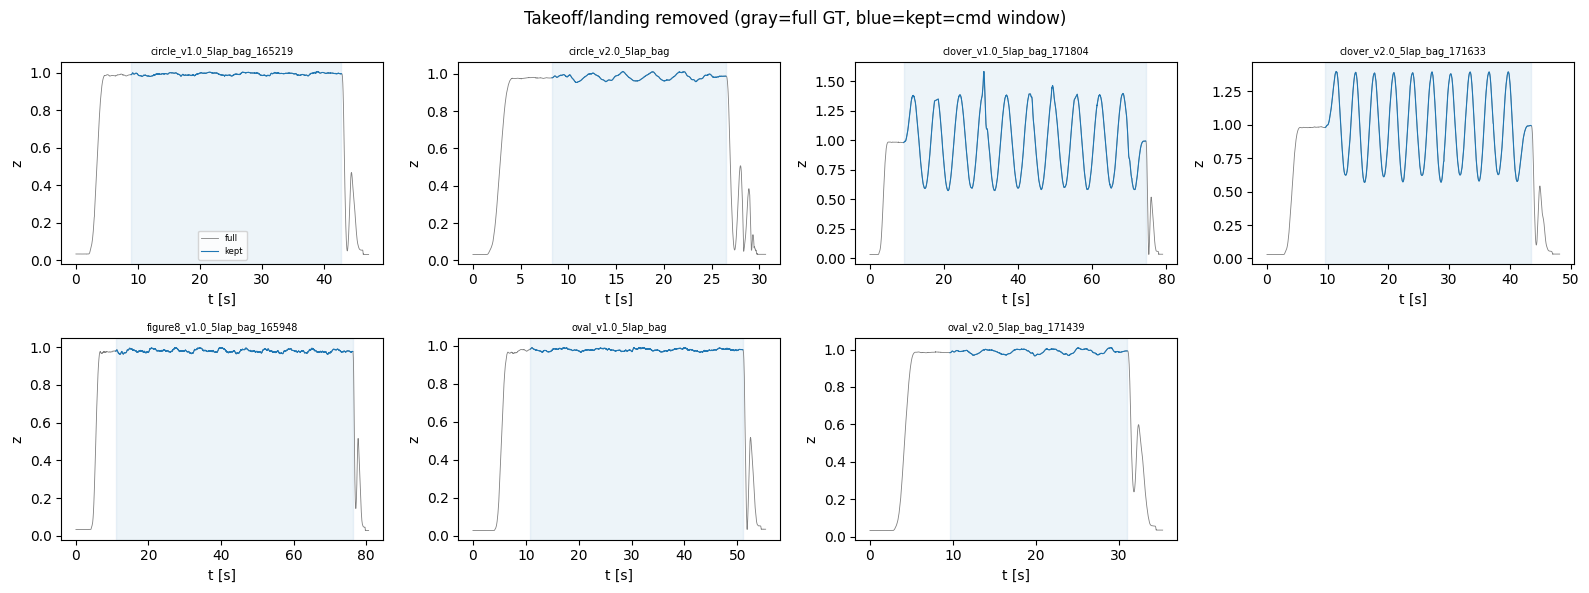

In [3]:
def flight_window(cmd):
    t = _t(cmd); return float(t[0]), float(t[-1])

fig, axes = plt.subplots(2, 4, figsize=(16, 6)); axes = axes.ravel()
for k, d in enumerate(SELECTED):
    ds = load_dataset(d); t0, t1 = flight_window(ds['cmd'])
    tp = _t(ds['gt']); zp = _col(ds['gt'], 'poses.0.pose.position.z')   # GT z
    ax = axes[k]; ax.plot(tp-tp[0], zp, lw=.6, color='gray', label='full')
    m = (tp>=t0)&(tp<=t1); ax.plot(tp[m]-tp[0], zp[m], lw=.8, color='tab:blue', label='kept')
    ax.axvspan(t0-tp[0], t1-tp[0], color='tab:blue', alpha=.08)
    ax.set_title(d, fontsize=7); ax.set_xlabel('t [s]'); ax.set_ylabel('z')
    if k==0: ax.legend(fontsize=6)
for ax in axes[len(SELECTED):]: ax.axis('off')
fig.suptitle('Takeoff/landing removed (gray=full GT, blue=kept=cmd window)'); fig.tight_layout(); plt.show()

## 3. 타임스탬프 통일 → `unified.csv`
pose 는 **mocap ground-truth**(`/poses` 의 `poses.0`=cf231). `[t0,t1]` 을 100 Hz 격자로 만들고 각 신호를 `np.interp` 로 보간해 한 표로 병합. **GT 드롭 구간은 그 구간을 덮는 온보드 추정(`/cf231/pose`)으로 교차채움**하고 `gap=1` 로 표시. (mocap 이 지연 전송이 아니라 실제 미측정이라 header.stamp 재배치는 불가 → 대신 추정으로 채움.) 각 셋 폴더에 `unified.csv` 저장.


In [4]:
def unify(ds):
    t0, t1 = flight_window(ds['cmd'])
    grid = np.arange(t0, t1, 1.0/RATE); T = {'t': grid - t0}
    # pose = mocap GT. ①(0,0,0) 원점 센티넬(트래킹 상실) 제거 → ②GT 드롭은 온보드 추정으로
    # 교차채움 → ③둘 다 없으면 보간. gap=1 표시.
    def valid_t(rows, px, py, pz):
        t = _t(rows); X,Y,Z = _col(rows,px),_col(rows,py),_col(rows,pz)
        return t, ~((np.abs(X)<0.03)&(np.abs(Y)<0.03)&(Z<0.10))
    tg, gg = valid_t(ds['gt'], 'poses.0.pose.position.x','poses.0.pose.position.y','poses.0.pose.position.z')
    te, ge = valid_t(ds['est'], 'pose.position.x','pose.position.y','pose.position.z')
    tgv, tev = tg[gg], te[ge]
    nom = float(np.median(np.diff(tgv)))
    ix = np.clip(np.searchsorted(tgv, grid), 1, len(tgv)-1)
    gap = (tgv[ix]-tgv[ix-1]) > GAP_K*nom
    T['gap'] = gap.astype(int)
    for a in 'xyz':
        g = np.interp(grid, tgv, _col(ds['gt'], f'poses.0.pose.position.{a}')[gg])
        e = np.interp(grid, tev, _col(ds['est'], f'pose.position.{a}')[ge])
        T['pose_'+a] = np.where(gap, e, g)
    for q in 'xyzw':
        g = np.interp(grid, tgv, _col(ds['gt'], f'poses.0.pose.orientation.{q}')[gg])
        e = np.interp(grid, tev, _col(ds['est'], f'pose.orientation.{q}')[ge])
        T['quat_'+q] = np.where(gap, e, g)
    tc = _t(ds['cmd'])
    for a in 'xyz':
        T['cmd_'+a]  = np.interp(grid, tc, _col(ds['cmd'], f'pose.position.{a}'))
        T['cmd_v'+a] = np.interp(grid, tc, _col(ds['cmd'], f'twist.linear.{a}'))
    vp = _values(ds['pwm']); tw = _t(ds['pwm'])
    for i in range(vp.shape[1]): T[f'm{i+1}'] = np.interp(grid, tw, vp[:, i])
    vi = _values(ds['imu']); ti = _t(ds['imu'])
    for i, nm in enumerate(['ax','ay','az','gx','gy','gz'][:vi.shape[1]]):
        T[nm] = np.interp(grid, ti, vi[:, i])
    if ds['status'] is not None:
        T['battery'] = np.interp(grid, _t(ds['status']), _col(ds['status'], 'battery_voltage'))
    return T

for d in SELECTED:
    T = unify(load_dataset(d)); cols = list(T)
    with open(os.path.join(TRAIN, d, 'unified.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(cols); w.writerows(np.column_stack([T[c] for c in cols]))
    print(f'{d:32s} {len(T["t"]):5d} rows  cols={len(cols)}  batt={"battery" in T}')

circle_v1.0_5lap_bag_165219       3391 rows  cols=25  batt=False
circle_v2.0_5lap_bag              1821 rows  cols=26  batt=True


clover_v1.0_5lap_bag_171804       6533 rows  cols=26  batt=True
clover_v2.0_5lap_bag_171633       3391 rows  cols=26  batt=True


figure8_v1.0_5lap_bag_165948      6533 rows  cols=25  batt=False
oval_v1.0_5lap_bag                4019 rows  cols=25  batt=False


oval_v2.0_5lap_bag_171439         2135 rows  cols=26  batt=True


## 4. pose(GT) 지연/드롭 점검
GT(mocap `/poses`)는 약 100~120 Hz. 연속 타임스탬프 간격이 중앙값의 `2.5×` 를 넘으면 지연/드롭으로 본다. 이 구간은 §3 에서 온보드 추정으로 교차채움하고 `gap=1` 로 표시했다.


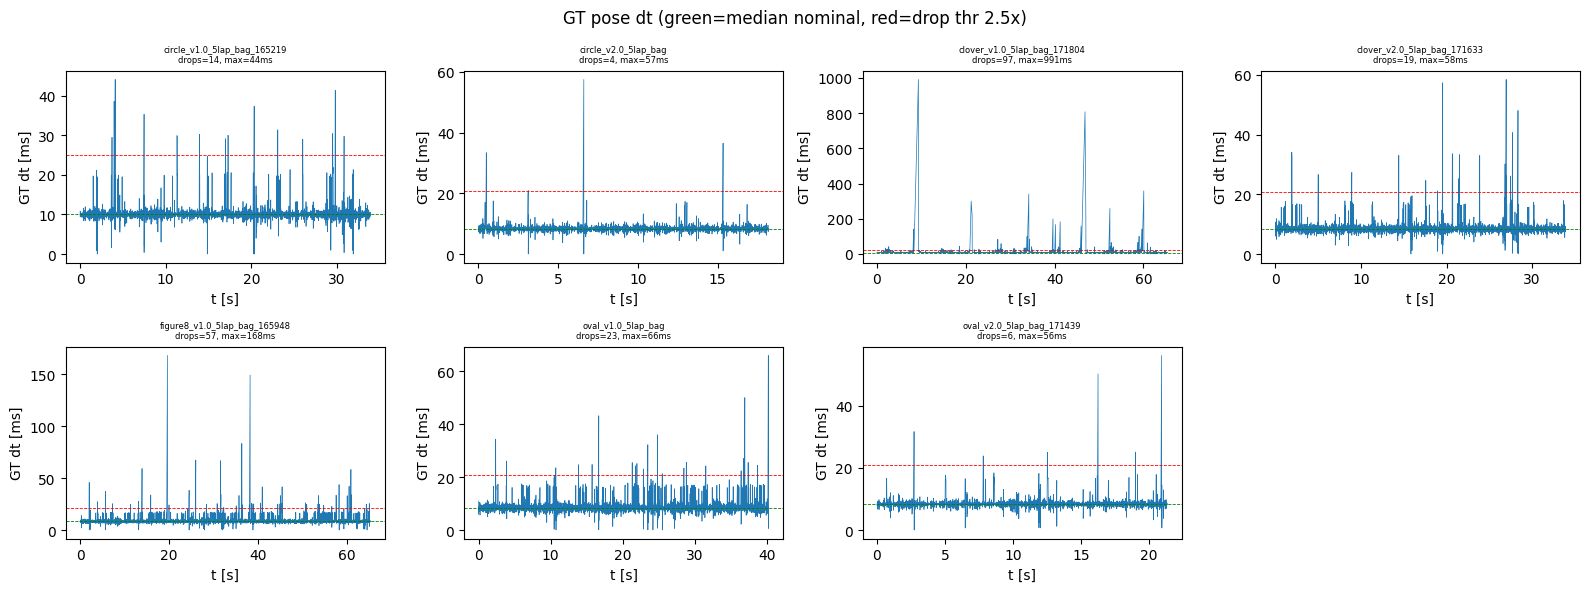

dataset                              n maxdt(ms)  drops lost(s)
circle_v1.0_5lap_bag_165219       3325        44     14    0.47
circle_v2.0_5lap_bag              2173        57      4    0.15
clover_v1.0_5lap_bag_171804       6911       991     97    7.22
clover_v2.0_5lap_bag_171633       3973        58     19    0.64
figure8_v1.0_5lap_bag_165948      7467       168     57    2.10
oval_v1.0_5lap_bag                4656        66     23    0.68
oval_v2.0_5lap_bag_171439         2530        56      6    0.21


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6)); axes = axes.ravel()
rows = []
for k, d in enumerate(SELECTED):
    ds = load_dataset(d); t0, t1 = flight_window(ds['cmd'])
    tp = _t(ds['gt']); tp = tp[(tp>=t0)&(tp<=t1)]        # GT 타임스탬프
    dt = np.diff(tp); nom = float(np.median(dt))
    big = dt > GAP_K*nom
    rows.append((d, len(tp), dt.max()*1000, int(big.sum()), float(dt[big].sum()) if big.any() else 0))
    ax = axes[k]; ax.plot(tp[1:]-tp[0], dt*1000, lw=.5)
    ax.axhline(nom*1000, color='green', ls='--', lw=.6); ax.axhline(GAP_K*nom*1000, color='red', ls='--', lw=.6)
    ax.set_title(f'{d}\ndrops={int(big.sum())}, max={dt.max()*1000:.0f}ms', fontsize=6)
    ax.set_xlabel('t [s]'); ax.set_ylabel('GT dt [ms]')
for ax in axes[len(SELECTED):]: ax.axis('off')
fig.suptitle('GT pose dt (green=median nominal, red=drop thr 2.5x)'); fig.tight_layout(); plt.show()

print(f'{"dataset":32s} {"n":>5} {"maxdt(ms)":>9} {"drops":>6} {"lost(s)":>7}')
for r in rows: print(f'{r[0]:32s} {r[1]:>5} {r[2]:>9.0f} {r[3]:>6} {r[4]:>7.2f}')

## 5. 배터리 전압 vs 모터 출력
전압이 시간에 따라 떨어지면 출력(PWM)이 어떻게 변하는가? (status 토픽이 있는 셋만 — 나머지는 status 미기록)


circle_v2.0_5lap_bag             V 3.59->3.44  dV/dt=-0.0053  dPWM/dt=+103  corr=-0.38
clover_v1.0_5lap_bag_171804      V 3.47->3.26  dV/dt=-0.0017  dPWM/dt=+34  corr=-0.15


clover_v2.0_5lap_bag_171633      V 3.51->3.38  dV/dt=-0.0035  dPWM/dt=+61  corr=-0.58
oval_v2.0_5lap_bag_171439        V 3.55->3.40  dV/dt=-0.0042  dPWM/dt=+74  corr=-0.35


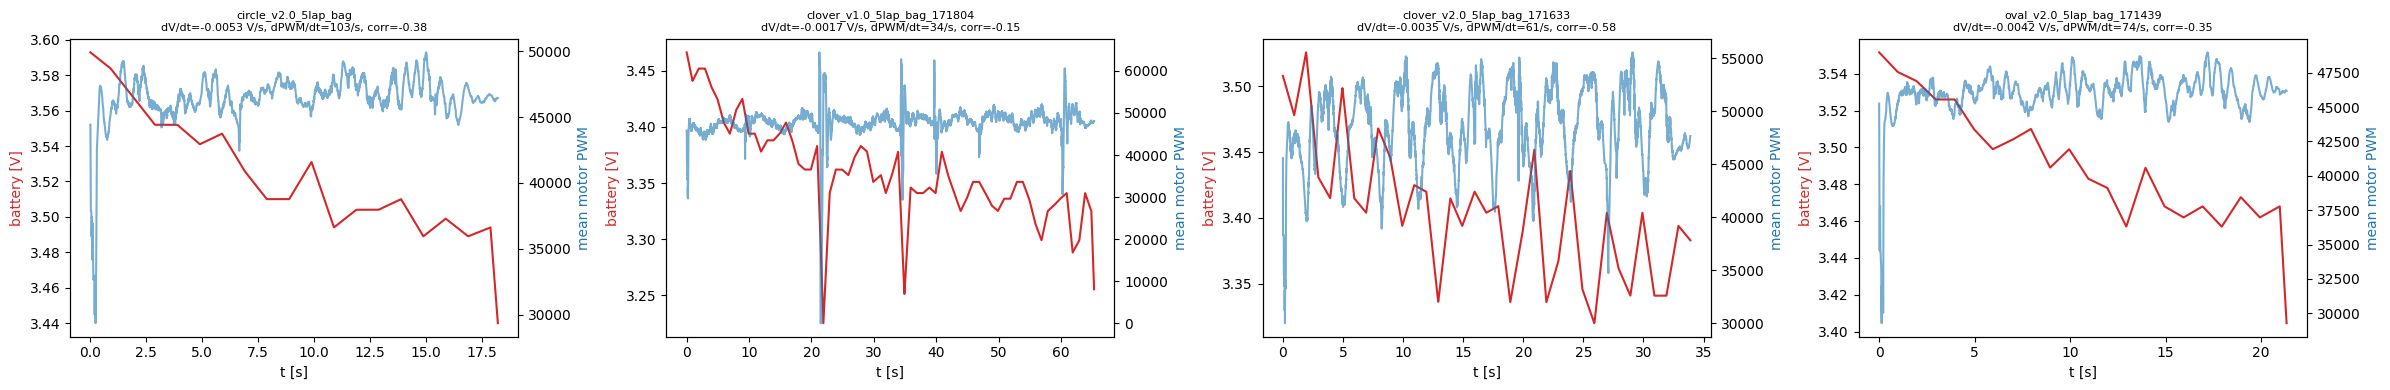

In [6]:
batt = [d for d in SELECTED if load_dataset(d)['status'] is not None]
fig, axes = plt.subplots(1, len(batt), figsize=(6*len(batt), 4), squeeze=False)
for j, d in enumerate(batt):
    T = unify(load_dataset(d)); t = T['t']; v = T['battery']
    pwm = np.mean([T[f'm{i}'] for i in (1,2,3,4)], axis=0)
    dv = np.polyfit(t, v, 1)[0]; dp = np.polyfit(t, pwm, 1)[0]; c = np.corrcoef(v, pwm)[0,1]
    a = axes[0][j]; a2 = a.twinx()
    a.plot(t, v, color='tab:red'); a2.plot(t, pwm, color='tab:blue', alpha=.6)
    a.set_xlabel('t [s]'); a.set_ylabel('battery [V]', color='tab:red')
    a2.set_ylabel('mean motor PWM', color='tab:blue')
    a.set_title(f'{d}\ndV/dt={dv:.4f} V/s, dPWM/dt={dp:.0f}/s, corr={c:+.2f}', fontsize=8)
    print(f'{d:32s} V {v[0]:.2f}->{v[-1]:.2f}  dV/dt={dv:+.4f}  dPWM/dt={dp:+.0f}  corr={c:+.2f}')
fig.tight_layout(); plt.show()

## 6. 교차채움이 자연스러운가?
드롭이 가장 많은 `clover_v1.0_5lap_bag_171804` 에서 채운 구간(빨강)이 GT(파랑)와 경계에서 매끄럽게 이어지는지 본다 — 최대 gap 줌 + 경계 위치 점프 정량화.


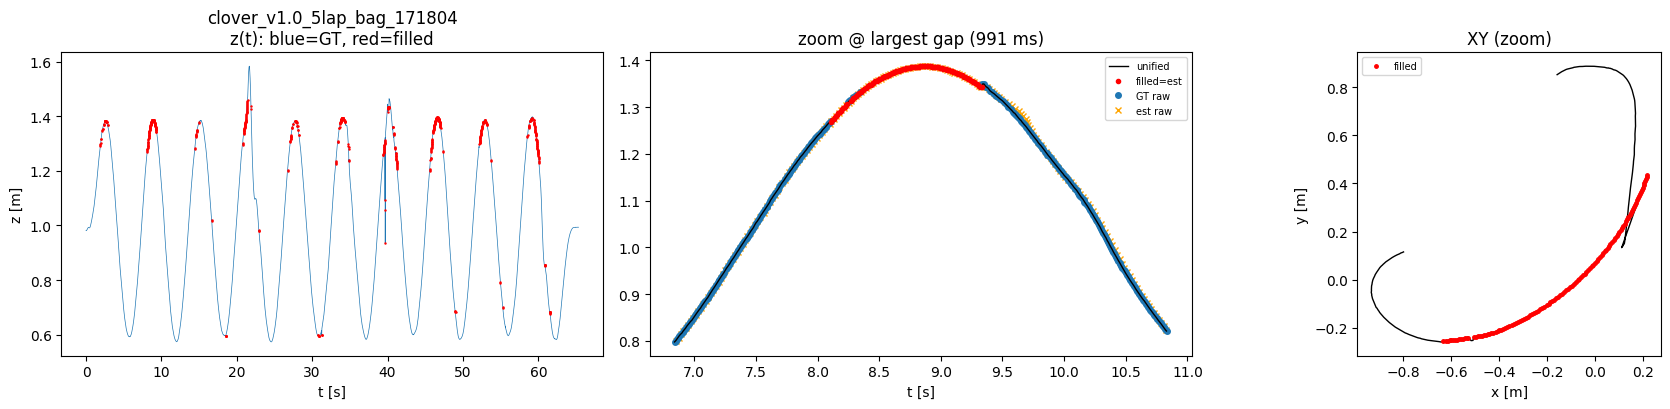

행당 이동:      중앙 7.70 mm, 최대 387.73 mm
gap 경계 이동:  중앙 22.29 mm, 최대 387.73 mm
→ 경계 점프가 평소 이동과 비슷하면 자연스러운 것(불연속 없음).


In [7]:
d = 'clover_v1.0_5lap_bag_171804'
ds = load_dataset(d); t0, t1 = flight_window(ds['cmd']); T = unify(ds)
t = T['t']; z = T['pose_z']; gap = T['gap'].astype(bool)
tg = _t(ds['gt']); zg = _col(ds['gt'], 'poses.0.pose.position.z')
te = _t(ds['est']); ze = _col(ds['est'], 'pose.position.z')
mg = (tg>=t0)&(tg<=t1); me = (te>=t0)&(te<=t1)
tg2, zg2 = tg[mg]-t0, zg[mg]; te2, ze2 = te[me]-t0, ze[me]
dtg = np.diff(tg2); gi = int(np.argmax(dtg)); gc = (tg2[gi]+tg2[gi+1])/2; w = 2.0
sel = (t>gc-w)&(t<gc+w)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.2))
ax[0].plot(t, z, lw=.5, color='tab:blue')
ax[0].plot(t[gap], z[gap], '.', ms=1.5, color='red')
ax[0].set_title(f'{d}\nz(t): blue=GT, red=filled'); ax[0].set_xlabel('t [s]'); ax[0].set_ylabel('z [m]')

ax[1].plot(t[sel], z[sel], '-', color='k', lw=1, label='unified', zorder=3)
ax[1].plot(t[sel & gap], z[sel & gap], '.', color='red', ms=6, label='filled=est', zorder=4)
m1=(tg2>gc-w)&(tg2<gc+w); ax[1].plot(tg2[m1], zg2[m1], 'o', color='tab:blue', ms=4, label='GT raw', zorder=2)
m2=(te2>gc-w)&(te2<gc+w); ax[1].plot(te2[m2], ze2[m2], 'x', color='orange', ms=4, label='est raw', zorder=1)
ax[1].set_title(f'zoom @ largest gap ({dtg[gi]*1000:.0f} ms)'); ax[1].set_xlabel('t [s]'); ax[1].legend(fontsize=7)

ax[2].plot(T['pose_x'][sel], T['pose_y'][sel], '-', color='k', lw=1)
ax[2].plot(T['pose_x'][sel&gap], T['pose_y'][sel&gap], '.', color='red', ms=5, label='filled')
ax[2].set_aspect('equal'); ax[2].set_title('XY (zoom)'); ax[2].set_xlabel('x [m]'); ax[2].set_ylabel('y [m]'); ax[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

# 경계 점프 정량화: gap 시작/끝에서 위치 이동이 평소보다 튀는가
xyz = np.column_stack([T['pose_x'], T['pose_y'], T['pose_z']])
step = np.linalg.norm(np.diff(xyz, axis=0), axis=1)
edge = np.diff(gap.astype(int)) != 0
print(f'행당 이동:      중앙 {np.median(step)*1000:.2f} mm, 최대 {step.max()*1000:.2f} mm')
print(f'gap 경계 이동:  중앙 {np.median(step[edge])*1000:.2f} mm, 최대 {step[edge].max()*1000:.2f} mm')
print('→ 경계 점프가 평소 이동과 비슷하면 자연스러운 것(불연속 없음).')

## 결론

- **pose = mocap GT**(`/poses`). 온보드 추정(`/cf231/pose`)이 아니라 실제 위치를 넣었다.
- **이착륙 제거**: `cmd_full_state` 구간으로 자르면 이륙 램프·착륙이 깔끔히 빠진다(§2 그림).
- **타임스탬프 통일**: 각 셋 `unified.csv` (100 Hz, pose(GT)·quat·`gap`·cmd(+vel)·모터PWM·IMU·battery).
- **GT 지연/드롭 & 복구**: mocap 드롭은 지연 전송이 아니라 실제 미측정(§header.stamp 확인). 그 구간을 덮는 **온보드 추정(`/cf231/pose`)으로 교차채움**(GT 드롭의 ~97 % 를 추정이 덮음)하고 `gap=1` 로 표시. **`clover_v1.0_5lap_bag_171804` 는 GT 드롭이 커 약 11 % 행이 추정으로 채워짐** → 학습 시 `gap==1` 행 마스킹/가중 고려.
- **배터리**: status 있는 4개 셋 모두 전압이 하강하는데 **mean PWM 은 오히려 상승**(corr < 0). 즉 출력이 낮아지는 게 아니라 **컨트롤러가 전압 강하를 PWM 을 올려 보상**한다.
